In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plot style for publication/thesis level
sns.set_theme(style="whitegrid")

# 1. Define the absolute path for Experiment B
file_path_B = r"C:\Users\Matias\Documents\Tesis\Vision-Aided-Beamformer\tests\dataset_out\Exp_C\benchmark_metrics.parquet" 

# Load the Parquet file into memory
df_b = pd.read_parquet(file_path_B)

# 2. General Summary
print("="*50)
print(f"TOTAL EXPERIMENTS RUN (Exp B): {len(df_b)}")
print("="*50)

# 3. Inspect Grid Variables (Verify all parameters)
print("\n[+] EXPLORED CONFIGURATION VARIABLES (Exp B):")
config_cols = ['mismatch_gain', 'mismatch_phase', 'isir_db', 'processor']
for col in config_cols:
    if col in df_b.columns:
        print(f"  - {col}: {df_b[col].unique().tolist()}")

# 4. Data Preview
display(df_b.head())

TOTAL EXPERIMENTS RUN (Exp B): 12

[+] EXPLORED CONFIGURATION VARIABLES (Exp B):
  - mismatch_gain: [0, 1, 3, 6]
  - mismatch_phase: [0]
  - isir_db: [0]
  - processor: ['MVDR_Oracle', 'MVDR_SPP', 'MPDR']


,processor,rt60,M,N_interferences,mismatch_pos,isir_db,mismatch_gain,mismatch_phase,use_wpe,exec_time_s,...,proc_CD,proc_SDR,proc_SIR,proc_SAR,Delta_STOI,Delta_PESQ,Delta_CD,Delta_SDR,Delta_SIR,Delta_SAR
0,MVDR_Oracle,0.6,8,1,0.0,0,0,0,True,24.104251,...,4.092859,5.046611,10.914268,6.686524,0.092786,0.227762,-0.244469,4.574766,9.833452,-5.121559
1,MVDR_SPP,0.6,8,1,0.0,0,0,0,True,25.835676,...,4.155306,4.160375,7.862054,7.232447,0.078739,0.158176,-0.182022,3.688529,6.781238,-4.575635
2,MPDR,0.6,8,1,0.0,0,0,0,True,26.515060,...,4.149378,4.353577,8.999554,6.693507,0.080851,0.177891,-0.187950,3.881731,7.918738,-5.114575
3,MVDR_Oracle,0.6,8,1,0.0,0,1,0,True,25.622880,...,4.041619,4.792647,12.592507,5.813526,0.084169,0.270291,-0.294217,4.320799,11.511682,-5.994512
4,MVDR_SPP,0.6,8,1,0.0,0,1,0,True,26.648003,...,4.092968,3.560943,8.370227,5.893041,0.068111,0.170651,-0.242868,3.089095,7.289402,-5.914996


<>:18: SyntaxWarning: invalid escape sequence '\D'
<>:18: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Matias\AppData\Local\Temp\ipykernel_3528\2059785943.py:18: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('Perceptual Improvement ($\Delta$ PESQ)', fontsize=12)


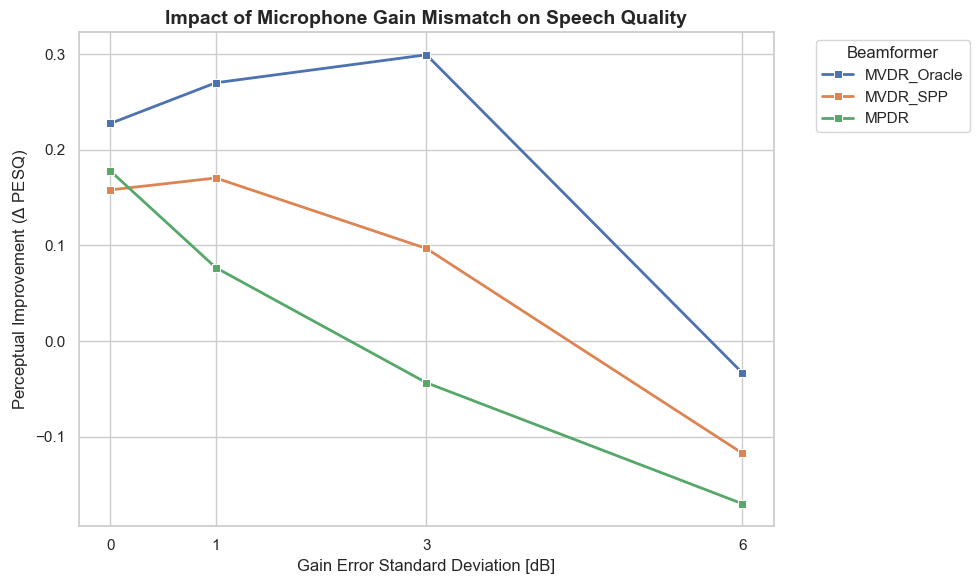

In [6]:
# Create a figure for the Gain Mismatch analysis
plt.figure(figsize=(10, 6))

# Line plot for gain error impact
sns.lineplot(
    data=df_b,
    x='mismatch_gain',
    y='Delta_PESQ',
    hue='processor',
    marker='s',
    errorbar=None,
    linewidth=2
)

# Format the plot for thesis quality
plt.title('Impact of Microphone Gain Mismatch on Speech Quality', fontsize=14, fontweight='bold')
plt.xlabel('Gain Error Standard Deviation [dB]', fontsize=12)
plt.ylabel('Perceptual Improvement ($\Delta$ PESQ)', fontsize=12)

# Ensure the X-axis ticks match our simulated discrete values
plt.xticks([0, 1, 3, 6])

plt.legend(title='Beamformer', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Save the figure in high resolution
plt.savefig("expB_gain_mismatch_pesq.pdf", dpi=300, bbox_inches='tight')
plt.show()

<>:19: SyntaxWarning: invalid escape sequence '\D'
<>:19: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Matias\AppData\Local\Temp\ipykernel_13524\2379071773.py:19: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('Separation Improvement ($\Delta$ SDR) [dB]', fontsize=12)


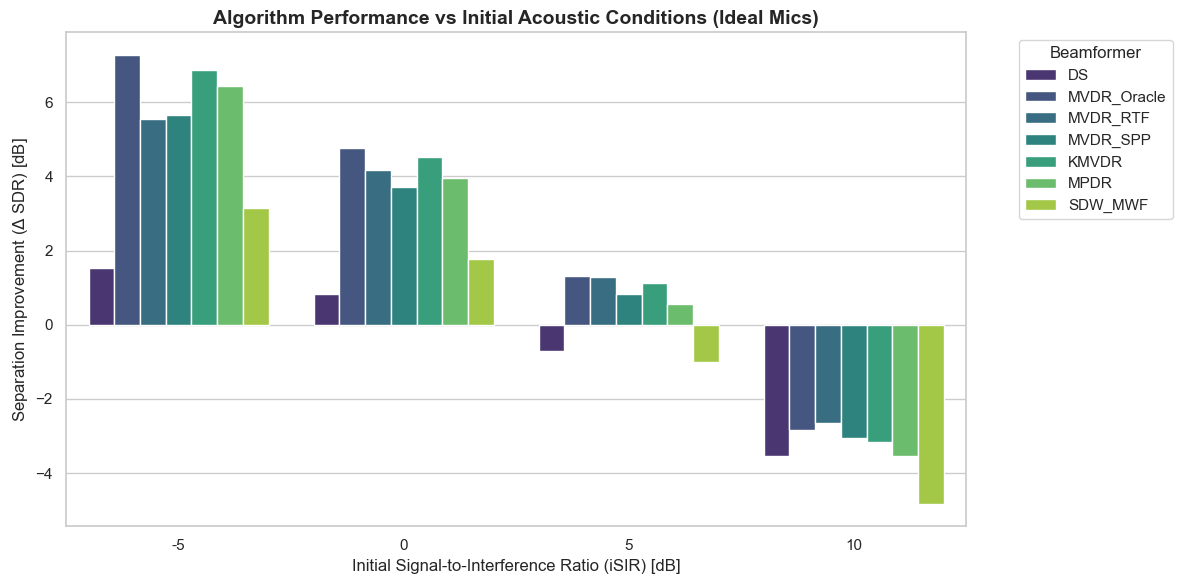

In [3]:
# Filter to isolate cases with NO hardware errors (ideal conditions)
df_b_ideal = df_b[(df_b['mismatch_gain'] == 0) & (df_b['mismatch_phase'] == 0)]

# Create a figure for the iSIR analysis
plt.figure(figsize=(12, 6))

# Use a bar plot to compare performance at different initial SIR levels
sns.barplot(
    data=df_b_ideal,
    x='isir_db',
    y='Delta_SDR',
    hue='processor',
    palette='viridis'
)

# Format the plot for thesis quality
plt.title('Algorithm Performance vs Initial Acoustic Conditions (Ideal Mics)', fontsize=14, fontweight='bold')
plt.xlabel('Initial Signal-to-Interference Ratio (iSIR) [dB]', fontsize=12)
plt.ylabel('Separation Improvement ($\Delta$ SDR) [dB]', fontsize=12)

plt.legend(title='Beamformer', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Save the figure in high resolution
plt.savefig("expB_isir_sensitivity.pdf", dpi=300, bbox_inches='tight')
plt.show()

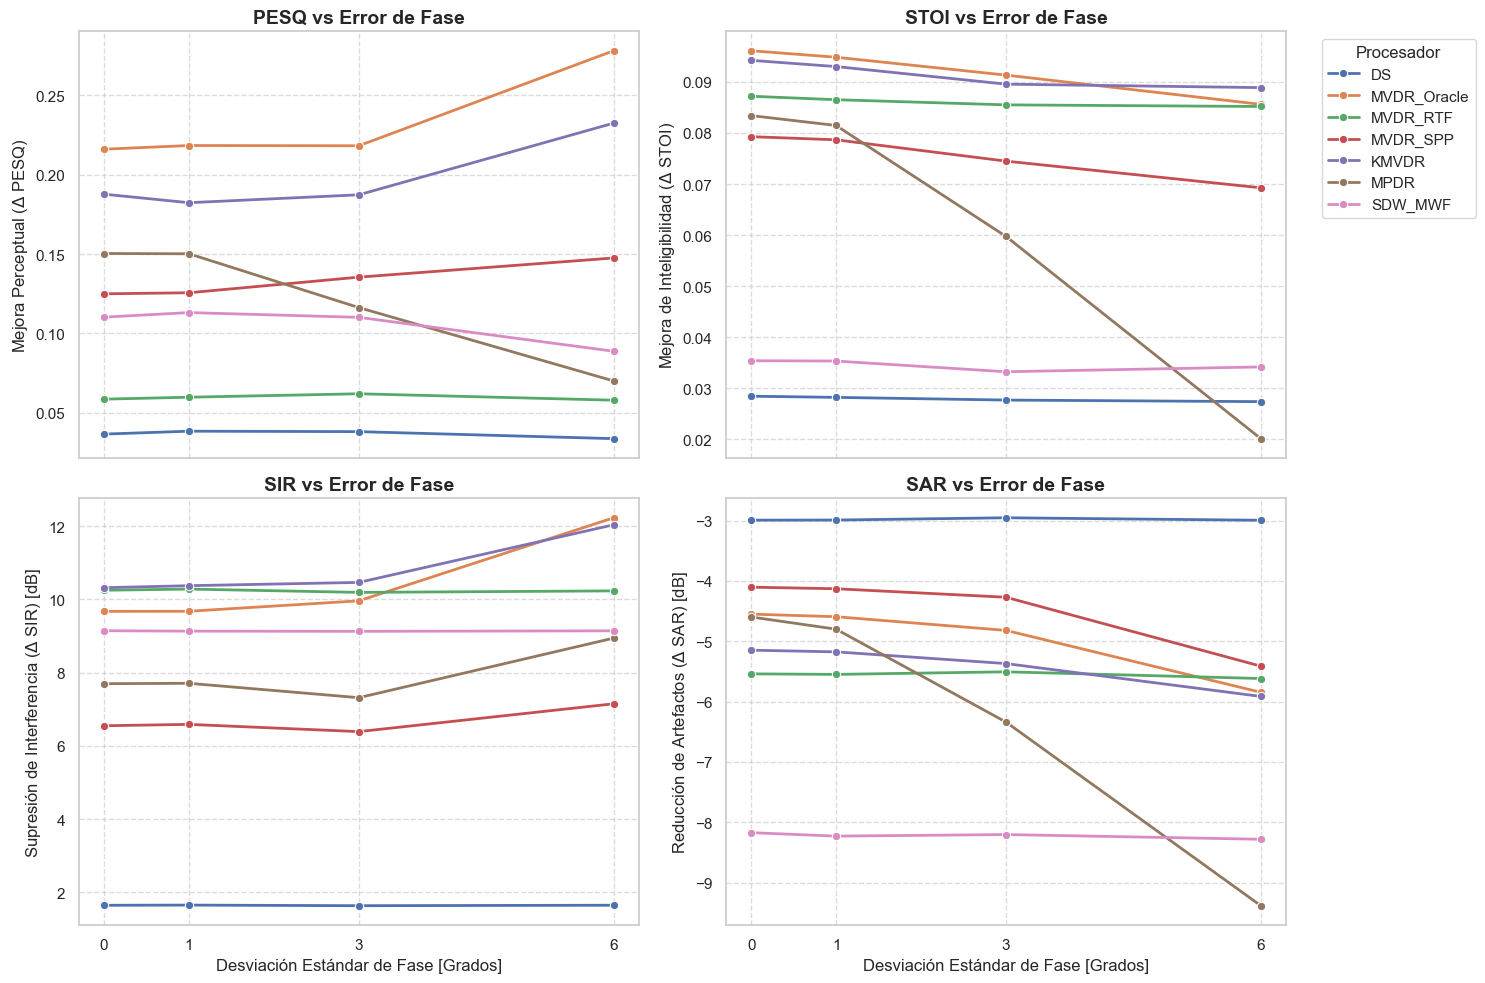

In [4]:
# 1. Isolate pure phase mismatch effects 
# We fix gain mismatch to 0 and initial SIR to 0 dB for a controlled analysis
df_phase = df_b[(df_b['mismatch_gain'] == 0) & (df_b['isir_db'] == 0)]

# 2. Create a 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True)
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

# 3. Define the metrics to plot and their respective Y-axis labels
metrics_to_plot = [
    ('Delta_PESQ', r'Mejora Perceptual ($\Delta$ PESQ)'),
    ('Delta_STOI', r'Mejora de Inteligibilidad ($\Delta$ STOI)'),
    ('Delta_SIR', r'Supresión de Interferencia ($\Delta$ SIR) [dB]'),
    ('Delta_SAR', r'Reducción de Artefactos ($\Delta$ SAR) [dB]')
]

# 4. Generate each subplot
for i, (metric, ylabel) in enumerate(metrics_to_plot):
    sns.lineplot(
        data=df_phase,
        x='mismatch_phase',
        y=metric,
        hue='processor',
        marker='o',
        ax=axes[i],
        errorbar=None, 
        linewidth=2
    )
    
    # Format individual subplots
    axes[i].set_title(f'{metric.replace("Delta_", "")} vs Error de Fase', fontsize=14, fontweight='bold')
    axes[i].set_ylabel(ylabel, fontsize=12)
    
    # Force X-axis ticks to match the exact evaluated standard deviations
    axes[i].set_xticks([0, 1, 3, 6])
    
    # Only show X-axis label on the bottom row to keep the layout clean
    if i >= 2:
        axes[i].set_xlabel('Desviación Estándar de Fase [Grados]', fontsize=12)
    else:
        axes[i].set_xlabel('')
        
    # Add a grid for readability
    axes[i].grid(True, linestyle='--', alpha=0.7)
    
    # Remove individual legends to create a single global legend later
    if i != 1:
        axes[i].get_legend().remove()
    else:
        # Keep the legend only on the top-right plot and move it strictly outside
        axes[i].legend(title='Procesador', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)

# 5. Adjust overall layout and save the figure
plt.tight_layout()
plt.savefig("metrics_vs_phase_mismatch_expB.pdf", dpi=300, bbox_inches='tight')
plt.show()

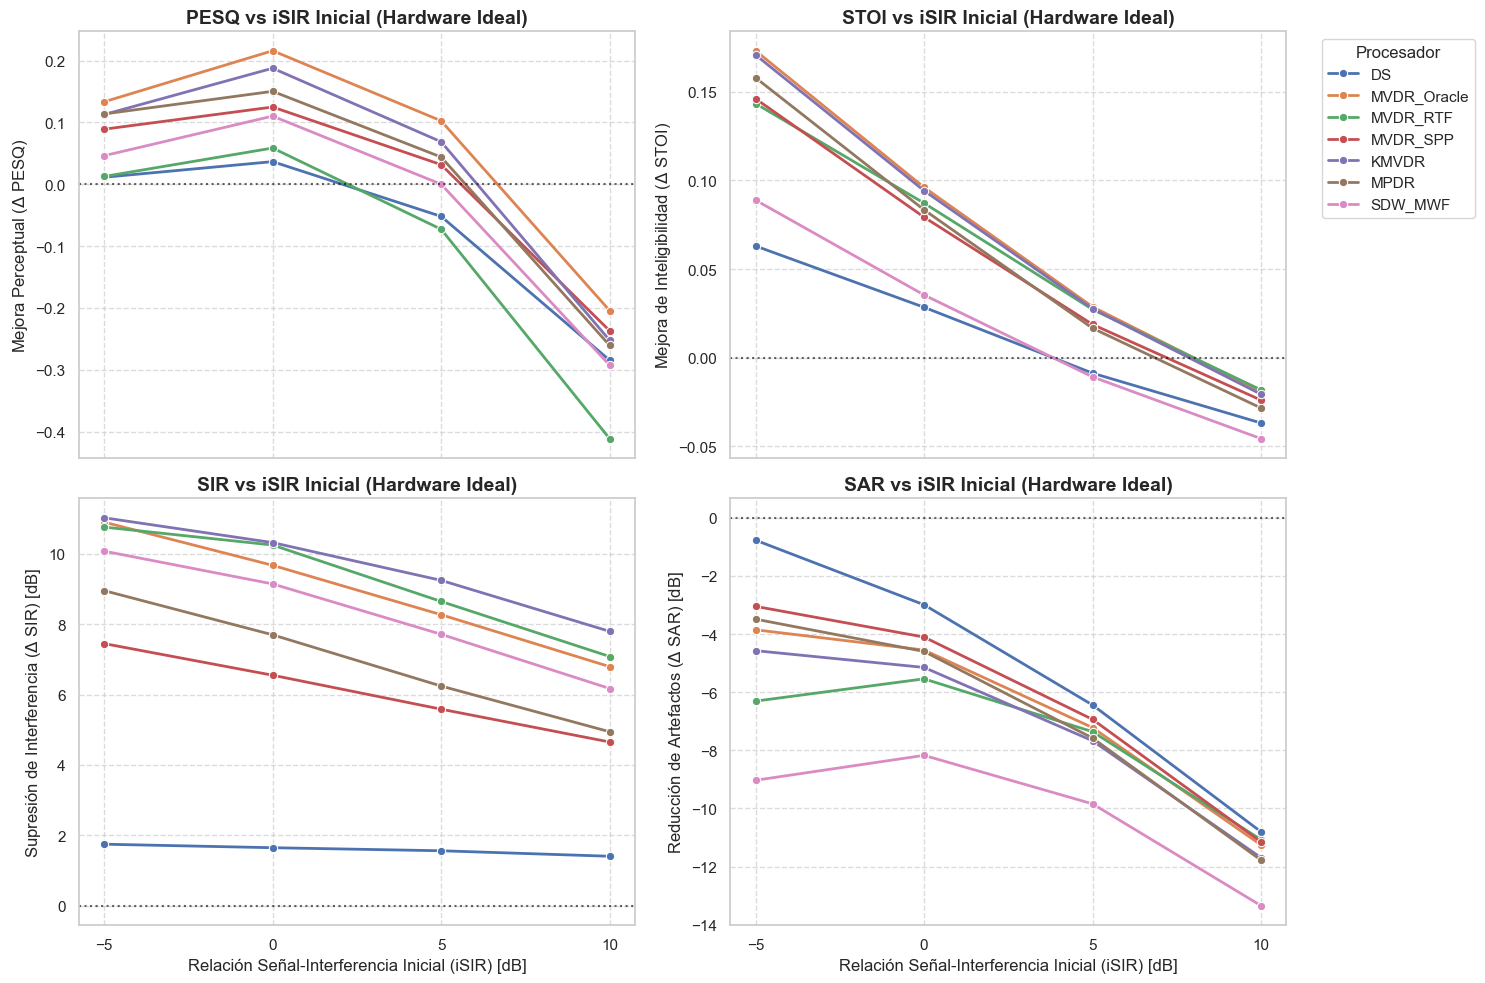

In [5]:
# 1. Isolate the "Ideal Hardware" scenario from Experiment B
# We strictly filter for 0 gain mismatch and 0 phase mismatch
df_ideal_mics = df_b[(df_b['mismatch_gain'] == 0) & (df_b['mismatch_phase'] == 0)]

# 2. Create a 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True)
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

# 3. Define the metrics to plot and their respective Y-axis labels
metrics_to_plot = [
    ('Delta_PESQ', r'Mejora Perceptual ($\Delta$ PESQ)'),
    ('Delta_STOI', r'Mejora de Inteligibilidad ($\Delta$ STOI)'),
    ('Delta_SIR', r'Supresión de Interferencia ($\Delta$ SIR) [dB]'),
    ('Delta_SAR', r'Reducción de Artefactos ($\Delta$ SAR) [dB]')
]

# 4. Generate each subplot
for i, (metric, ylabel) in enumerate(metrics_to_plot):
    sns.lineplot(
        data=df_ideal_mics,
        x='isir_db',
        y=metric,
        hue='processor',
        marker='o',
        ax=axes[i],
        errorbar=None, 
        linewidth=2
    )
    
    # Format individual subplots
    axes[i].set_title(f'{metric.replace("Delta_", "")} vs iSIR Inicial (Hardware Ideal)', fontsize=14, fontweight='bold')
    axes[i].set_ylabel(ylabel, fontsize=12)
    
    # Force X-axis ticks to match the exact simulated iSIR/iSNR values
    axes[i].set_xticks([-5, 0, 5, 10])
    
    # Only show X-axis label on the bottom row to keep the layout clean
    if i >= 2:
        axes[i].set_xlabel('Relación Señal-Interferencia Inicial (iSIR) [dB]', fontsize=12)
    else:
        axes[i].set_xlabel('')
        
    # Add a grid for readability
    axes[i].grid(True, linestyle='--', alpha=0.7)
    
    # Draw a horizontal line at Y=0 to clearly show where algorithms start hurting the signal
    axes[i].axhline(0, color='black', linewidth=1.5, linestyle=':', alpha=0.6)
    
    # Remove individual legends to create a single global legend later
    if i != 1:
        axes[i].get_legend().remove()
    else:
        # Keep the legend only on the top-right plot and move it strictly outside
        axes[i].legend(title='Procesador', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)

# 5. Adjust overall layout and save the figure
plt.tight_layout()
plt.savefig("metrics_vs_isir_ideal_hardware_expB.pdf", dpi=300, bbox_inches='tight')
plt.show()

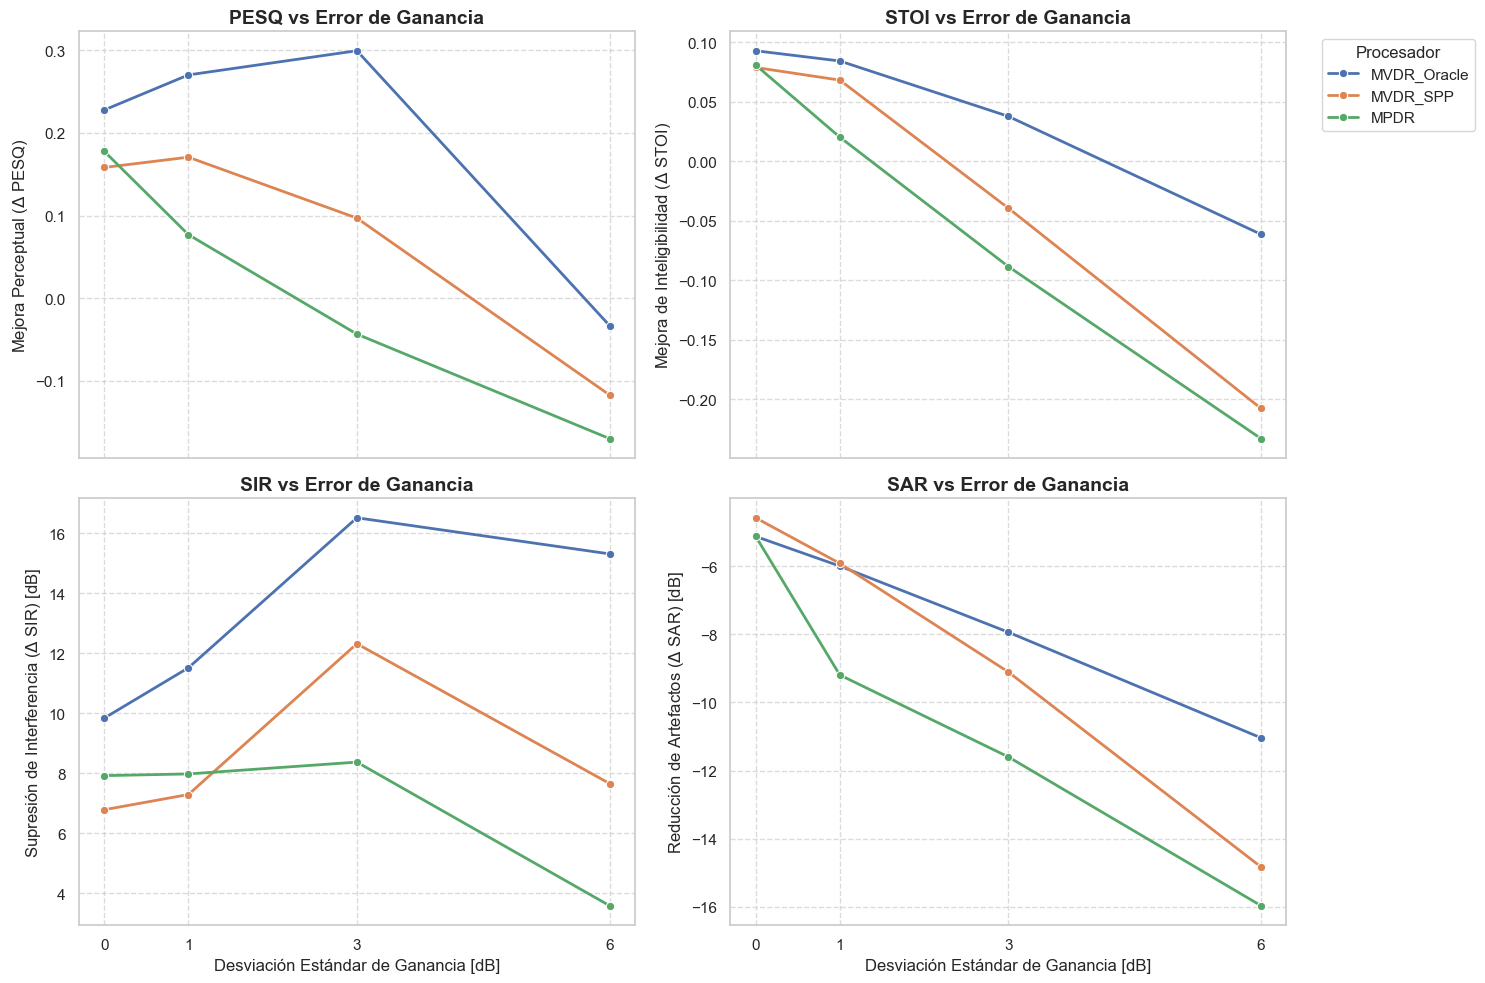

In [7]:
# 1. Isolate pure gain mismatch effects 
# Fijamos el error de fase en 0 y el SIR inicial en 0 dB para un análisis controlado
df_gain = df_b[(df_b['mismatch_phase'] == 0) & (df_b['isir_db'] == 0)]

# 2. Create a 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True)
axes = axes.flatten()

# 3. Define the metrics to plot
metrics_to_plot = [
    ('Delta_PESQ', r'Mejora Perceptual ($\Delta$ PESQ)'),
    ('Delta_STOI', r'Mejora de Inteligibilidad ($\Delta$ STOI)'),
    ('Delta_SIR', r'Supresión de Interferencia ($\Delta$ SIR) [dB]'),
    ('Delta_SAR', r'Reducción de Artefactos ($\Delta$ SAR) [dB]')
]

# 4. Generate each subplot
for i, (metric, ylabel) in enumerate(metrics_to_plot):
    sns.lineplot(
        data=df_gain,
        x='mismatch_gain', # Ahora variamos la ganancia en el eje X
        y=metric,
        hue='processor',
        marker='o',
        ax=axes[i],
        errorbar=None, 
        linewidth=2
    )
    
    # Formateo de títulos y ejes
    axes[i].set_title(f'{metric.replace("Delta_", "")} vs Error de Ganancia', fontsize=14, fontweight='bold')
    axes[i].set_ylabel(ylabel, fontsize=12)
    
    # Ajustamos los ticks a los valores evaluados en el Experimento B
    axes[i].set_xticks([0, 1, 3, 6])
    
    if i >= 2:
        axes[i].set_xlabel('Desviación Estándar de Ganancia [dB]', fontsize=12)
    else:
        axes[i].set_xlabel('')
        
    axes[i].grid(True, linestyle='--', alpha=0.7)
    
    # Manejo de la leyenda global
    if i != 1:
        axes[i].get_legend().remove()
    else:
        axes[i].legend(title='Procesador', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)

plt.tight_layout()
# Guardamos con un nombre descriptivo para el Experimento B
plt.savefig("metrics_vs_gain_mismatch_expB.pdf", dpi=300, bbox_inches='tight')
plt.show()